<a href="https://colab.research.google.com/github/manika-lamba/SP26-LIS4_5693/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 6: Text Networks

In this lab assignment, we will learn to perform text network analysis using `textnets` library.

*Note: Before starting this lab assignment, please complete the Introduction to Text Networks notebook*

## Learning Objectives

In this lab, you will:

- Construct a text corpus from raw data
- Apply tokenization and normalization techniques
- Build and interpret a document–term network
- Compute and analyze network-based importance measures (degree, BiRank)
- Generate and interpret a term–term projection network
- Detect and analyze communities (themes) in text data
- Critically reflect on the advantages and limitations of network-based text analysis

## Installing and Import Libraries

In [ ]:
!pip install textnets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.2/212.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 56.9 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninsta

**Restart the runtime in order to run the rest of the code**

In [ ]:
import textnets as tn

For reproducibility of results, it is advisable to document (or fix) the initial seed for the pseudorandom number generator. The seed is set at import time and is contained in the params object, which also holds a few other global parameters.



In [ ]:
tn.params

Parameter              Value         
--------------------   --------------
seed                   6032          
autodownload           False         
figsize                (16, 9)       
lang                   en_core_web_sm
progress_bar           True          
resolution_parameter   0.1           
tuning_parameter       0.5

You can also set a random seed and change the other global parameters. Following line of code hels you ensure that results are reproducible across runs of your script [see Sandve et al. 2013](https://textnets.readthedocs.io/en/stable/bibliography.html#id9).


In [ ]:
tn.params["seed"] = 42

## Prepare your Corpus

A textnet is built from a collection—or corpus—of texts, so we use the Corpus class to get our data ready. The following snippets assume that you have imported textnets as above.

Let's construct the corpus from the example data:

In [ ]:
corpus = tn.Corpus(tn.examples.moon_landing, lang="en")

What is this moon_landing example all about?

**Click on the output below to see what’s in our corpus.**

In [ ]:
corpus

<Corpus with 7 documents using language model 'en_core_web_sm'>

## Create Network

Next, we create the textnet:

In [ ]:
t = tn.Textnet(corpus.tokenized(), min_docs=1)

0docs [00:00, ?docs/s]

In [ ]:
t

Textnet,Docs: 7,Terms: 23,Edges: 36


We’re using tokenized with all defaults, so textnets is removing stop words, applying stemming, and removing punctuation marks, numbers, URLs and the like. However, we’re overriding the default setting for min_docs, opting to keep even words that appear in only one document (that is, a single newspaper headline).

When dealing with large corpora, you may also want to supply the argument remove_weak_edges=True to remove edges with a weight far below the average. This will result in a sparser graph.

Let’s take a look:

## Visualize & Analyze

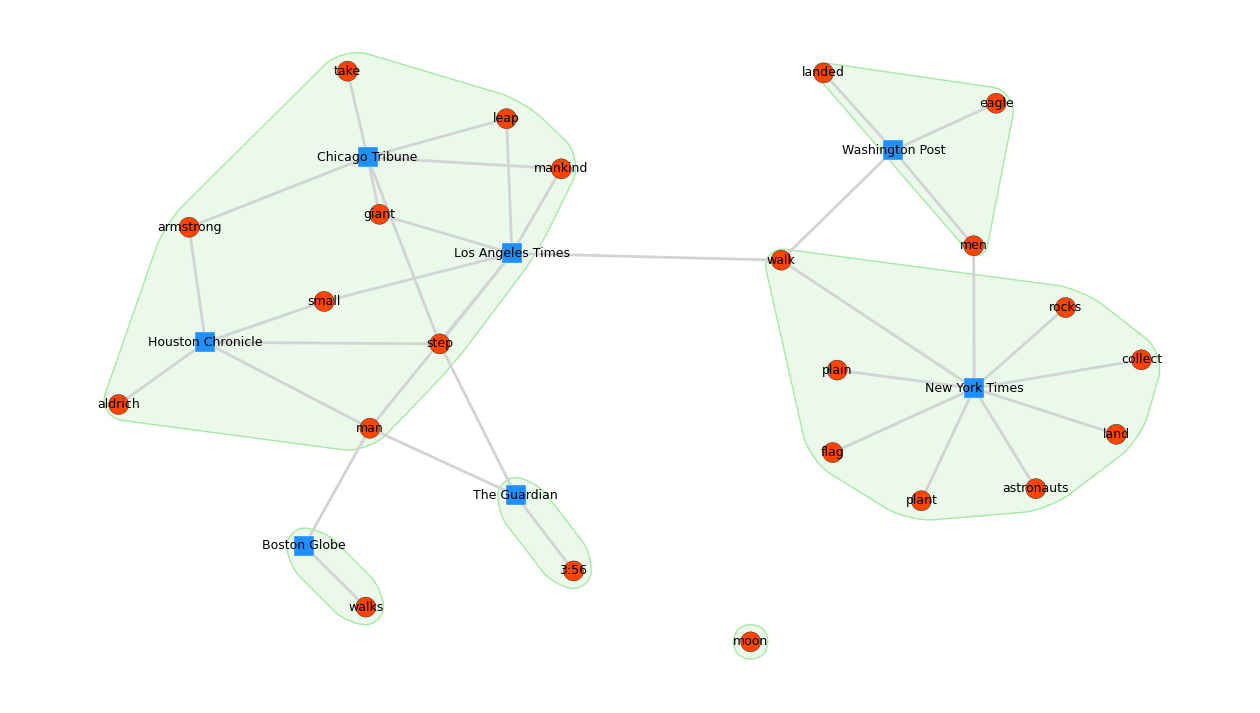

In [ ]:
t.plot(label_nodes=True,
       show_clusters=True)

The `show_clusters` options marks the partitions found by the Leiden community detection algorithm [see here](https://leidenalg.readthedocs.io/en/stable/multiplex.html). It identifies document–term groups that appear to form part of the same theme in the texts.

You may be wondering: why is the moon drifting off by itself in the network plot? That’s because the word moon appears exactly once in each document, so its *tf-idf* value for each document is 0.

Let’s visualize the same thing again, but this time scale the nodes according to their BiRank (a centrality measure for bipartite networks) and the edges according to their weights.

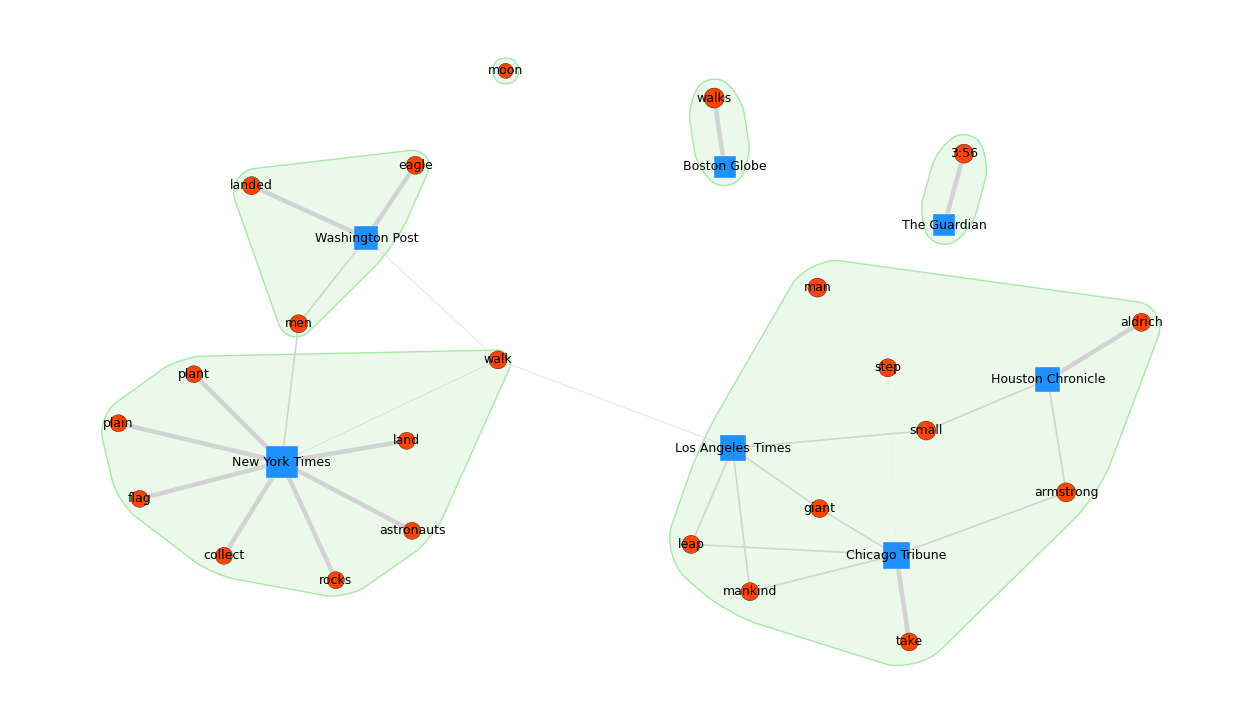

In [ ]:
t.plot(label_nodes=True,
       show_clusters=True,
       scale_nodes_by="birank",
       scale_edges_by="weight")

Clusters within the one-mode term-to-term projection can be interpreted as indicating latent themes, similar to the "topics" identified by topic modeling algorithms.

In [ ]:
terms = t.project(node_type=tn.TERM, connected=True)

In [ ]:
terms.top_cluster_nodes()

,nodes,size
cluster,,
0,"[mankind, giant, leap, armstrong, small, step,...",11
1,"[collect, astronauts, plain, plant, land, flag...",8
2,"[eagle, landed, walk]",3


We can also visualize the projected networks.

First, the network of newspapers:

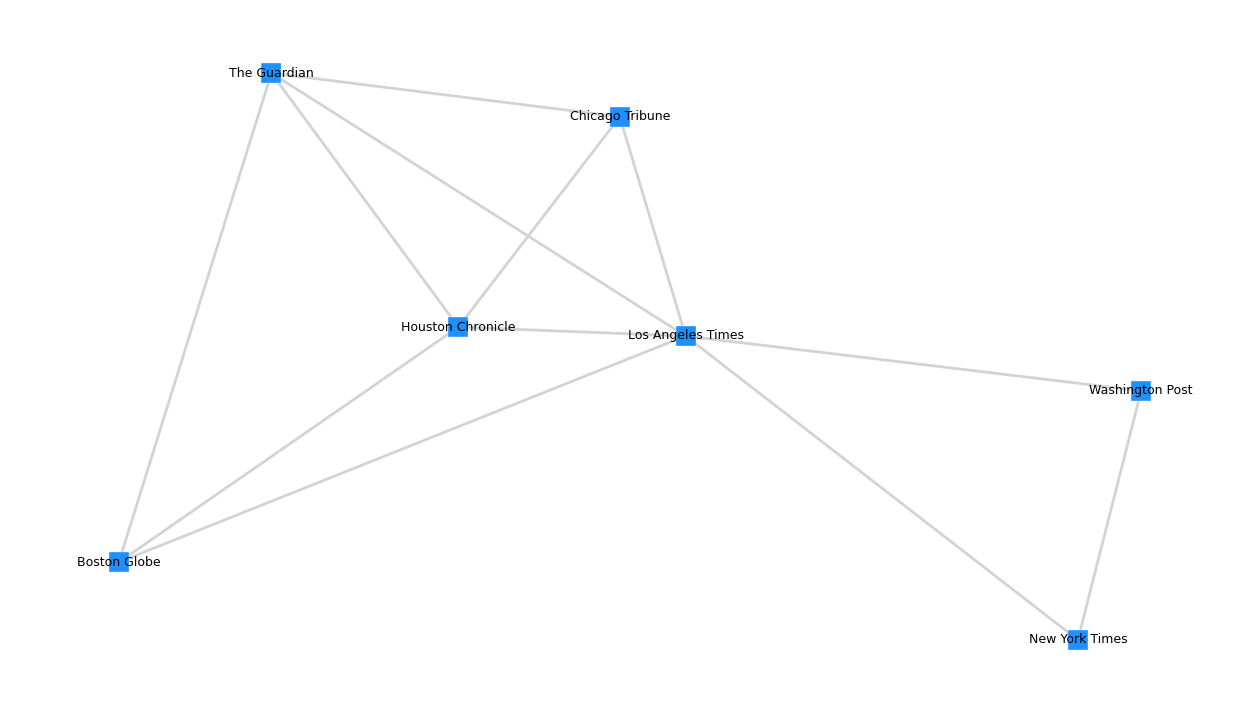

In [ ]:
papers = t.project(node_type=tn.DOC)
papers.plot(label_nodes=True)

As before in the bipartite network, we can see the Houston Chronicle, Chicago Tribune and Los Angeles Times cluster more closely together.

Next, the term network:

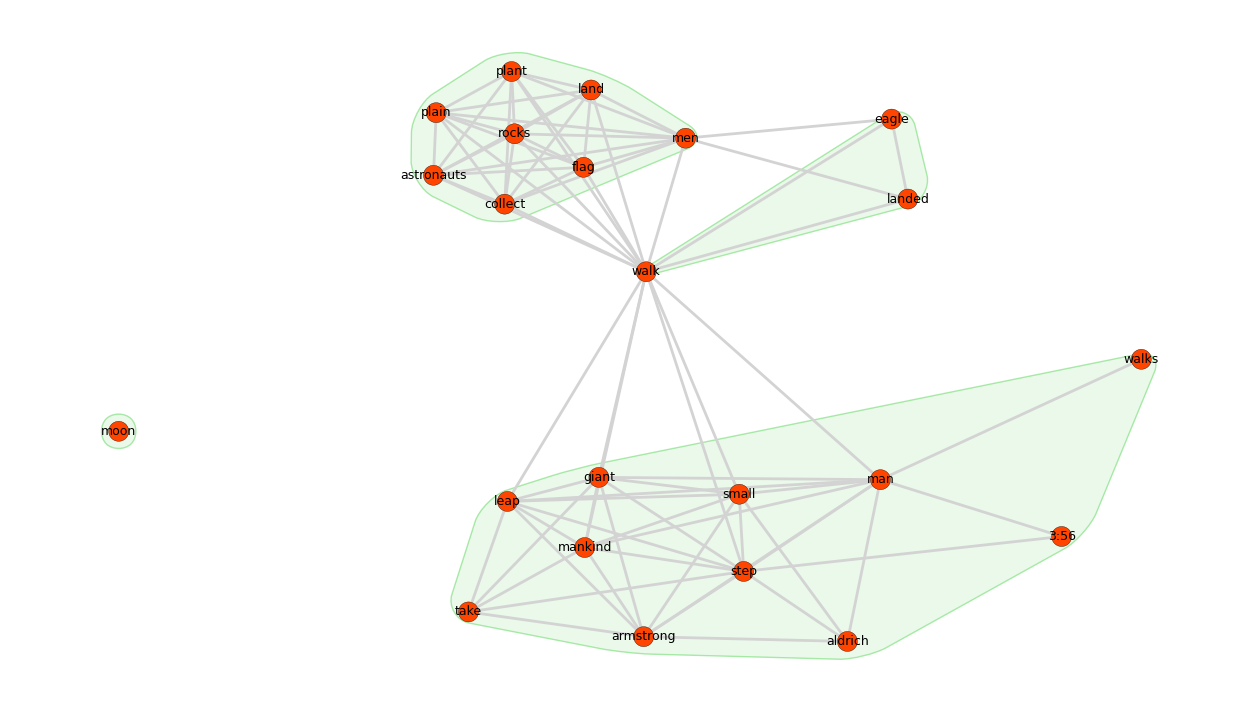

In [ ]:
words = t.project(node_type=tn.TERM)
words.plot(label_nodes=True,
           show_clusters=True)

Aside from visualization, we can also analyze our corpus using network metrics. For instance, documents with high betweenness centrality (or “cultural betweenness”; [Bail 2016](https://textnets.readthedocs.io/en/stable/bibliography.html#id6)) might link together themes, thereby stimulating exchange across symbolic divides.

In [ ]:
papers.top_betweenness()

,0
Los Angeles Times,10.0
Chicago Tribune,0.0
Boston Globe,0.0
Houston Chronicle,0.0
New York Times,0.0
The Guardian,0.0
Washington Post,0.0


As we can see, the Los Angeles Times is a cultural bridge linking the headline themes of the East Coast newspapers to the others.

In [ ]:
words.top_betweenness()

,0
walk,110.000000
man,26.500000
small,15.250000
men,14.000000
step,11.500000
mankind,7.166667
giant,7.166667
leap,7.166667
armstrong,3.250000
flag,0.000000


It’s because the Times uses the word “walk” in its headline, linking the “One Small Step” cluster to the “Man on Moon” cluster.

We can produce the term network plot again, this time scaling nodes according to their betweenness centrality, and pruning edges from the network using “backbone extraction” [Serrano et al., 2009].

We can also use color_clusters (instead of show_clusters) to color nodes according to their partition.

And we can filter node labels, labeling only those nodes that have a betweenness centrality score above the median. This is particularly useful in high-order networks where labeling every single node would cause too much visual clutter.

/usr/local/lib/python3.12/dist-packages/textnets/network.py:895: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  return quad(integrand, 0, norm_weight, args=(degree))
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in _edge_significance (vectorized)
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in _edge_significance (vectorized)
  result = getattr(ufunc, method)(*inputs, **kwargs)


0edges [00:00, ?edges/s]

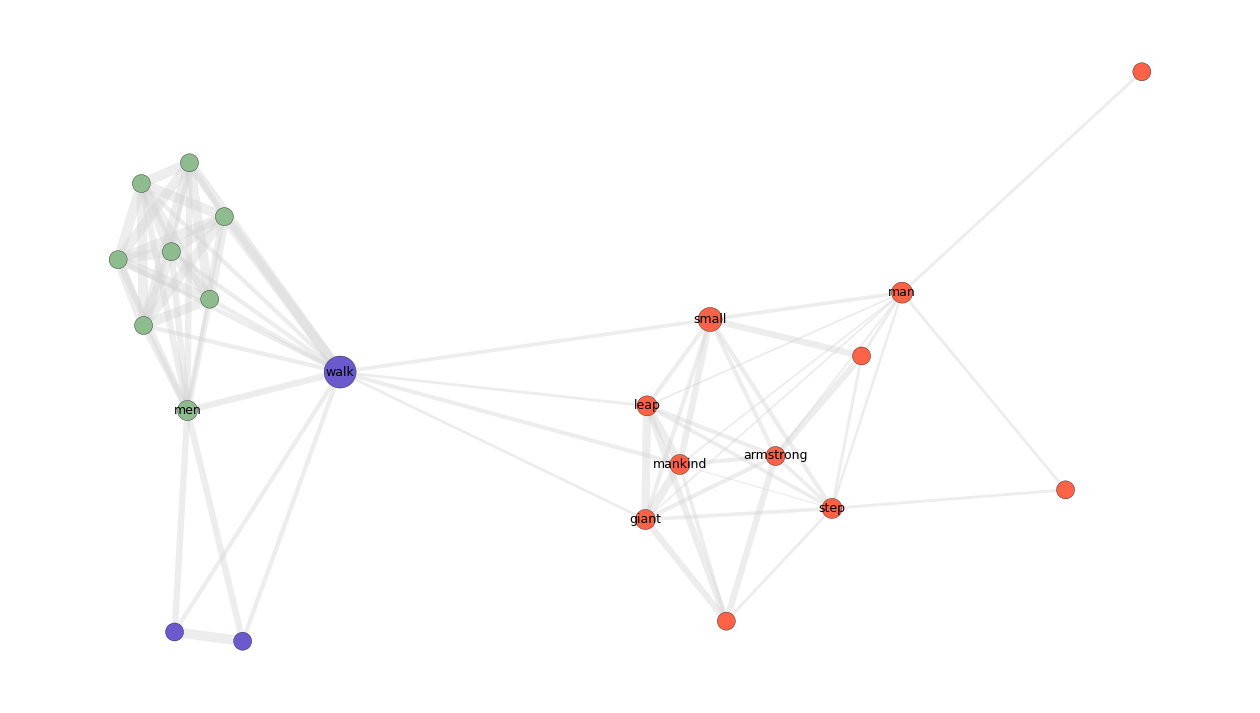

In [ ]:
words.plot(label_nodes=True,
           scale_nodes_by="betweenness",
           color_clusters=True,
           alpha=0.5,
           edge_width=[10*w for w in words.edges["weight"]],
           edge_opacity=0.4,
           node_label_filter=lambda n: n.betweenness() > words.betweenness.median())

Another measure we can use is the textual spanning measure introduced by [Stoltz and Taylor 2019](https://textnets.readthedocs.io/en/stable/bibliography.html#id13), which can help identify “discursive holes” in the document-to-document network.



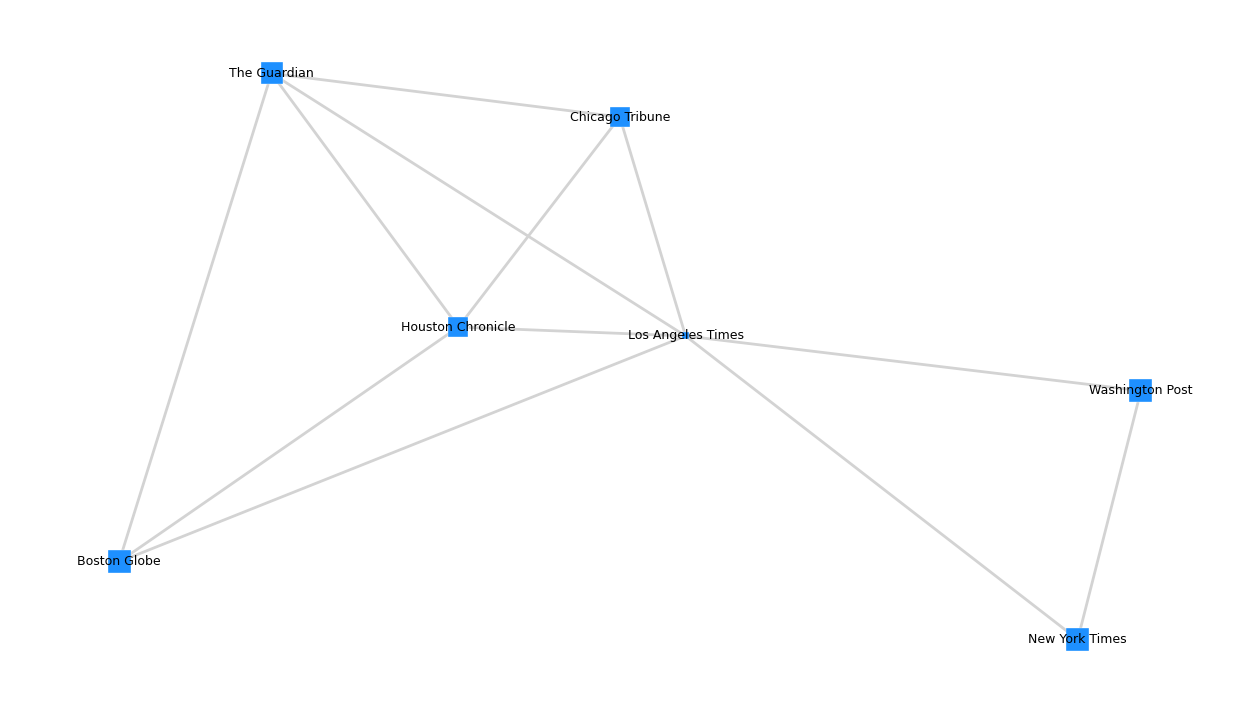

In [ ]:
papers.plot(label_nodes=True,
            scale_nodes_by="spanning")

Larger document nodes are similar to nodes that are dissimilar from one another, so they can be thought of as spanning a wider “distance” in the discursive field than the smaller ones.

## Saving Networks and Plots

You can save both the network that underlies a textnet as well as visualizations. Assuming you want to save the projected term network, called words, that we created above, you can do so as follows:



In [ ]:
words.save_graph("term_network.gml")

This will create a file in the current directory in Graph Modeling Language (GML) format. This can then be opened by Pajek, yEd, Gephi and other programs. Consult the docs for Textnet.save_graph for a list of supported formats.

If you want to save a plot of a network, use savefig. Supported file formats include SVG, PNG, TIFF, EPS and PDF.

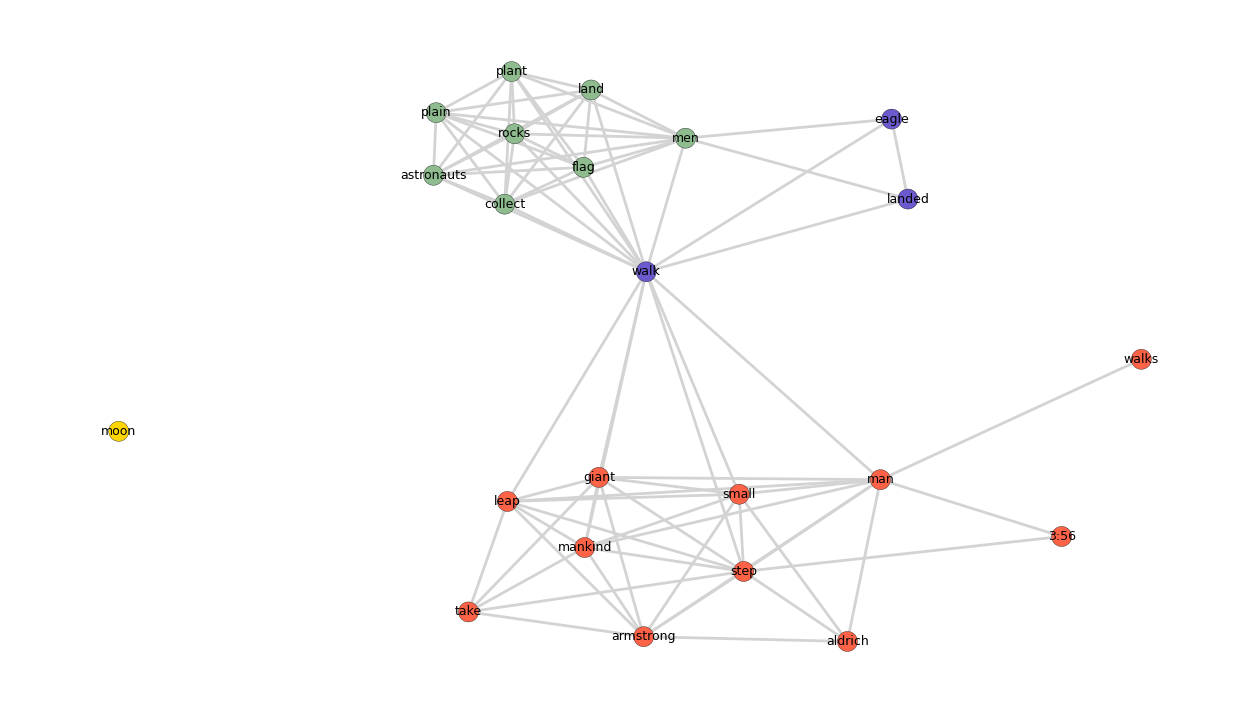

In [ ]:
words.plot(label_nodes=True, color_clusters=True)
tn.savefig("term_network.svg")

You can also save the plots produced by textnets in a variety of image formats. Use savefig, a function provided by matplotlib. Supported formats include PNG, SVG, and EPS.

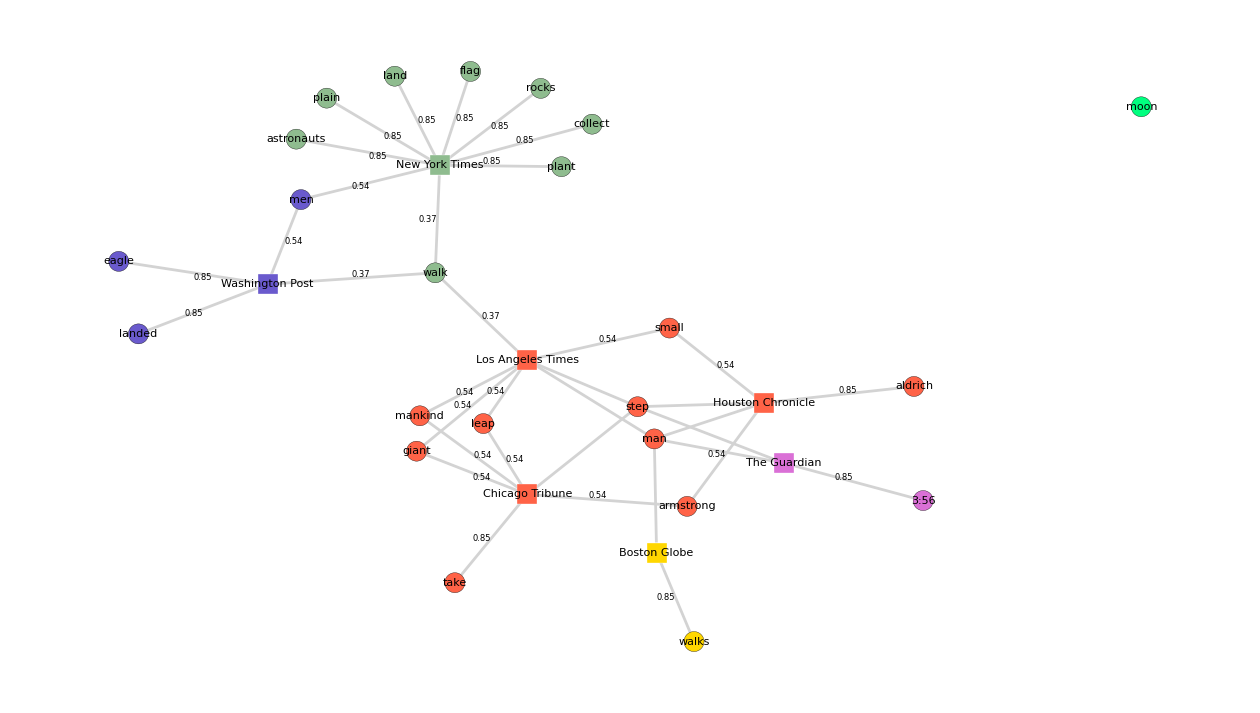

In [ ]:
import matplotlib.pyplot as plt
t.plot(label_nodes=True,
       node_label_size=8,
       label_edges=True,
       edge_label_size=6,
       edge_label_filter=lambda e: e["weight"] > 0.3,
       color_clusters=True,
       kamada_kawai_layout=True)
plt.savefig("moon_landing.eps")

In [ ]:
!ls *.eps

moon_landing.eps
